# Churn Labeling - Non-Contractual Setting

Phương pháp:
1. Tính IPT (Inter-Purchase Time) cho từng user
2. Tính Lapse Point = μ + 2σ của IPT
3. Gán nhãn Churn = 1 nếu Recency trong Target Window > Lapse Point

**Không data leakage**: nhãn chỉ dựa trên hành vi trong Target Window, không dùng thông tin từ Feature Window để gán nhãn.

In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

PROJECT_ROOT = r'c:\Users\Admin\data_driven_marketing'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')

df = pd.read_pickle(os.path.join(DATA_DIR, 'df_full.pkl'))

# Chuẩn hóa cột thời gian
if 'visitStartTime_datetime' in df.columns:
    df['event_date'] = pd.to_datetime(df['visitStartTime_datetime'], errors='coerce')
elif 'date' in df.columns:
    df['event_date'] = pd.to_datetime(df['date'], errors='coerce')
else:
    df['event_date'] = pd.to_datetime(df['visitStartTime'], unit='s', errors='coerce')

df['fullVisitorId'] = df['fullVisitorId'].astype(str)

print('Shape:', df.shape)
print('Date range:', df['event_date'].min(), '->', df['event_date'].max())

Shape: (1708337, 60)
Date range: 2016-08-01 07:00:12 -> 2018-05-01 06:56:58


In [14]:
# ==============================================================
# BƯỚC 1: Tính IPT (Inter-Purchase Time) - CHỈ DỰA TRÊN GIAO DỊCH MUA
# Chỉ tính trên các khách hàng đã từng phát sinh doanh thu (revenue > 0)
# ==============================================================

# Lọc CHỈ các session có giao dịch mua hàng thực sự
purchases = (
    df[df['transactionRevenue'] > 0][['fullVisitorId', 'event_date']]
    .drop_duplicates()
    .sort_values(['fullVisitorId', 'event_date'])
    .copy()
)

print(f"Tổng số giao dịch mua: {len(purchases):,}")
print(f"Số khách hàng đã mua: {purchases['fullVisitorId'].nunique():,}")

# Tính khoảng cách giữa các lần MUA liên tiếp
purchases['prev_purchase_date'] = purchases.groupby('fullVisitorId')['event_date'].shift(1)
purchases['ipt_days'] = (purchases['event_date'] - purchases['prev_purchase_date']).dt.days

# Chỉ giữ các khách hàng có >= 2 lần mua mới tính được IPT
ipt_series = purchases['ipt_days'].dropna()

# Số khách hàng mua lặp lại (repeat buyers)
repeat_buyers = purchases[purchases['prev_purchase_date'].notna()]['fullVisitorId'].nunique()

mu = ipt_series.mean()
sigma = ipt_series.std()
lapse_point = mu + 2 * sigma

print('='*60)
print('IPT Statistics (chỉ dựa trên giao dịch mua):')
print(f'  Số khách hàng mua lặp lại: {repeat_buyers:,}')
print(f'  Số cặp mua hàng có IPT:    {len(ipt_series):,}')
print(f'  Mean IPT (μ):               {mu:.2f} ngày')
print(f'  Std IPT (σ):                {sigma:.2f} ngày')
print(f'  Lapse Point (μ+2σ):         {lapse_point:.2f} ngày')
print('='*60)
print()
print(f'Ý nghĩa: Nếu khách hàng ĐÃ MUA không mua lại sau {lapse_point:.0f} ngày,')
print('         xác suất họ đã churn > 95%.')


Tổng số giao dịch mua: 18,514
Số khách hàng đã mua: 16,141
IPT Statistics (chỉ dựa trên giao dịch mua):
  Số khách hàng mua lặp lại: 1,541
  Số cặp mua hàng có IPT:    2,373
  Mean IPT (μ):               31.43 ngày
  Std IPT (σ):                50.19 ngày
  Lapse Point (μ+2σ):         131.81 ngày

Ý nghĩa: Nếu khách hàng ĐÃ MUA không mua lại sau 132 ngày,
         xác suất họ đã churn > 95%.


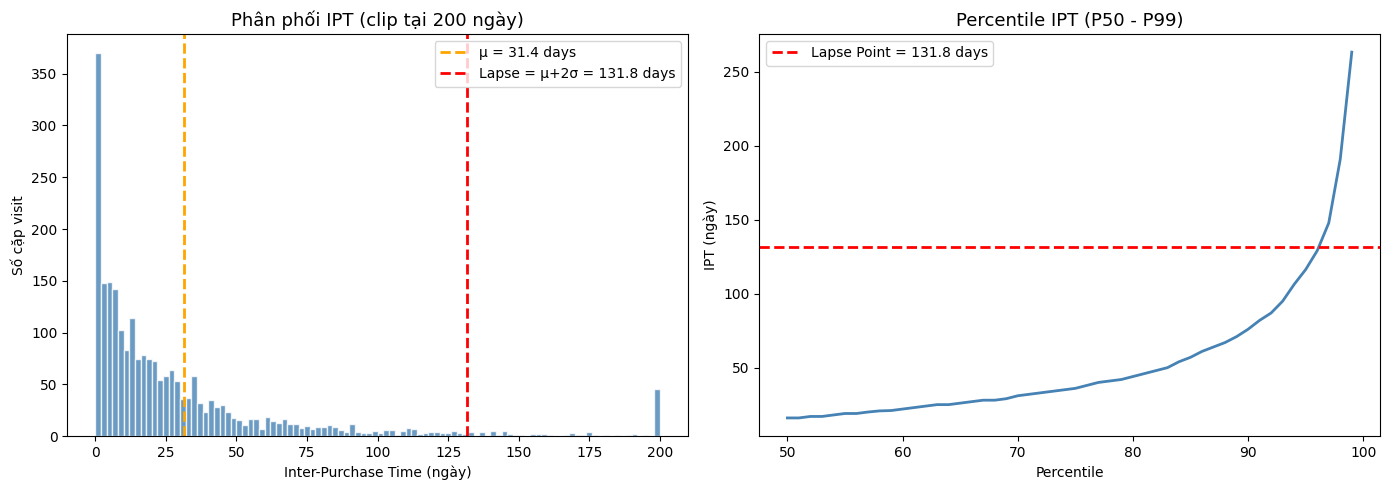

In [3]:
# Visualize phân phối IPT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(ipt_series.clip(upper=200), bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(mu, color='orange', linestyle='--', linewidth=2, label=f'μ = {mu:.1f} days')
axes[0].axvline(lapse_point, color='red', linestyle='--', linewidth=2, label=f'Lapse = μ+2σ = {lapse_point:.1f} days')
axes[0].set_title('Phân phối IPT (clip tại 200 ngày)', fontsize=13)
axes[0].set_xlabel('Inter-Purchase Time (ngày)')
axes[0].set_ylabel('Số cặp visit')
axes[0].legend()

# Percentile view
pcts = np.arange(50, 100, 1)
vals = np.percentile(ipt_series, pcts)
axes[1].plot(pcts, vals, color='steelblue', linewidth=2)
axes[1].axhline(lapse_point, color='red', linestyle='--', linewidth=2, label=f'Lapse Point = {lapse_point:.1f} days')
axes[1].set_title('Percentile IPT (P50 - P99)', fontsize=13)
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('IPT (ngày)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 2: Hàm gán nhãn Churn cho từng fold
#
# Logic KHÔNG data leakage:
#   - Feature Window: [feature_start, feature_end)  -> tính features
#   - Target Window : [target_start, target_end)    -> tính nhãn
#
# Churn = 1 nếu:
#   Recency = (target_end - last_visit_in_target_window) > lapse_point
#   HOẶC user hoàn toàn không xuất hiện trong Target Window
# ==============================================================

def label_churn_for_fold(df_raw, k, feature_days, target_days,
                          step_days, lapse_point_days, base_date):
    """
    Trả về DataFrame mức user với cột:
      - fullVisitorId
      - fold_id
      - feature_start, feature_end, target_start, target_end
      - last_visit_in_feature   : ngày visit cuối trong Feature Window
      - recency_past            : (feature_end - last_visit_in_feature)
      - is_churn_past           : recency_past > lapse_point_days
      - last_visit_in_target    : ngày visit cuối trong Target Window (NaT nếu không xuất hiện)
      - recency_days            : số ngày kể từ last visit in target đến target_end
      - churn                   : NHÃN (1 = churn, 0 = active)
    """
    feature_start = base_date + pd.Timedelta(days=step_days * (k - 1))
    feature_end   = feature_start + pd.Timedelta(days=feature_days)
    target_start  = feature_end
    target_end    = target_start + pd.Timedelta(days=target_days)
    if target_end > df_raw['event_date'].max():
        print(f'Skip Fold {k}: target_end {target_end.date()} > max_date {df_raw["event_date"].max().date()}')
        return None
    # Lọc Feature Window
    df_feat = df_raw[
        (df_raw['event_date'] >= feature_start) &
        (df_raw['event_date'] < feature_end)
    ]
    # CHỈ lấy các user ĐÃ MUA HÀNG trong Feature Window
    buyers_in_feature = df_feat[df_feat['transactionRevenue'] > 0]['fullVisitorId'].unique()
    # Nếu không có buyer nào, skip fold
    if len(buyers_in_feature) == 0:
        print(f'Skip Fold {k}: Không có khách hàng mua trong Feature Window')
        return None
    # Ngày MUA cuối cùng của mỗi buyer trong Feature Window
    last_purchase_feat = (
        df_feat[df_feat['transactionRevenue'] > 0]
        .groupby('fullVisitorId')['event_date']
        .max()
        .rename('last_purchase_in_feature')
        .reset_index()
    )
    # --- TARGET WINDOW ---
    df_tgt = df_raw[
        (df_raw['event_date'] >= target_start) &
        (df_raw['event_date'] < target_end)
    ]
    # Chỉ xét giao dịch MUA trong Target Window của các buyers
    df_tgt_buyers = df_tgt[
        (df_tgt['fullVisitorId'].isin(buyers_in_feature)) &
        (df_tgt['transactionRevenue'] > 0)
    ]
    # Ngày MUA cuối cùng trong Target Window
    last_purchase_tgt = (
        df_tgt_buyers.groupby('fullVisitorId')['event_date']
        .max()
        .rename('last_purchase_in_target')
        .reset_index()
    )
    # Merge
    fold_df = last_purchase_feat.merge(last_purchase_tgt, on='fullVisitorId', how='left')
    # --- TÍNH BIẾN QUÁ KHỨ (FEATURES) ---
    fold_df['recency_past'] = (feature_end - fold_df['last_purchase_in_feature']).dt.days
    fold_df['is_churn_past'] = (fold_df['recency_past'] > lapse_point_days).astype(int)
    # --- TÍNH NHÃN TƯƠNG LAI (TARGET) ---
    fold_df['purchased_in_target'] = fold_df['last_purchase_in_target'].notna().astype(int)
    # Recency tính từ lần mua cuối (feature hoặc target) đến target_end
    fold_df['last_purchase_for_recency'] = fold_df['last_purchase_in_target'].fillna(
        fold_df['last_purchase_in_feature']
    )
    fold_df['recency_days'] = (target_end - fold_df['last_purchase_for_recency']).dt.days
    # NHÃN CHURN: không mua lại trong Target Window sau lapse_point ngày
    fold_df['churn'] = (fold_df['recency_days'] > lapse_point_days).astype(int)
    # Metadata
    fold_df['fold_id']       = k
    fold_df['feature_start'] = feature_start
    fold_df['feature_end']   = feature_end
    fold_df['target_start']  = target_start
    fold_df['target_end']    = target_end
    n_buyers = len(fold_df)
    n_churn  = fold_df['churn'].sum()
    n_active = n_buyers - n_churn
    print(f'Fold {k}: Feature {feature_start.date()} -> {feature_end.date()} | '
          f'Target {target_start.date()} -> {target_end.date()} | '
          f'Buyers={n_buyers:,} | Churn={n_churn:,} ({n_churn/n_buyers*100:.1f}%) | '
          f'Active={n_active:,} ({n_active/n_buyers*100:.1f}%)')
    return fold_df[[
        'fullVisitorId', 'fold_id',
        'feature_start', 'feature_end', 'target_start', 'target_end',
        'last_purchase_in_feature', 'recency_past', 'is_churn_past',
        'last_purchase_in_target', 'purchased_in_target', 'recency_days', 'churn'
    ]]

print('Hàm label_churn_for_fold đã sẵn sàng.')

Hàm label_churn_for_fold đã sẵn sàng.


In [5]:
# ==============================================================
# BƯỚC 3: Thiết lập Time Windows (giống Train_test_split.ipynb)
# ==============================================================

FEATURE_DAYS = 168
TARGET_DAYS  = 92
STEP_DAYS    = 60

base_date = df['event_date'].min()
max_date  = df['event_date'].max()

print(f'Base date : {base_date.date()}')
print(f'Max date  : {max_date.date()}')
print(f'Lapse Point: {lapse_point:.2f} ngày')

Base date : 2016-08-01
Max date  : 2018-05-01
Lapse Point: 131.81 ngày


In [6]:
# ==============================================================
# BƯỚC 4: Chạy gán nhãn cho tất cả các fold
# ==============================================================

print(f'Lapse Point = {lapse_point:.2f} ngày\n')
print('='*90)

fold_labels = []
k = 1
while True:
    result = label_churn_for_fold(
        df_raw           = df,
        k                = k,
        feature_days     = FEATURE_DAYS,
        target_days      = TARGET_DAYS,
        step_days        = STEP_DAYS,
        lapse_point_days = lapse_point,
        base_date        = base_date
    )
    if result is None:
        break
    fold_labels.append(result)
    k += 1

print('='*90)
all_labels = pd.concat(fold_labels, ignore_index=True)
print(f'\nTổng số fold: {all_labels["fold_id"].nunique()}')
print(f'Tổng số records: {len(all_labels):,}')
print(f'Churn rate tổng: {all_labels["churn"].mean()*100:.2f}%')

Lapse Point = 131.81 ngày

Fold 1: Feature 2016-08-01 -> 2017-01-16 | Target 2017-01-16 -> 2017-04-18 | Buyers=4,840 | Churn=3,462 (71.5%) | Active=1,378 (28.5%)
Fold 2: Feature 2016-09-30 -> 2017-03-17 | Target 2017-03-17 -> 2017-06-17 | Buyers=4,472 | Churn=3,469 (77.6%) | Active=1,003 (22.4%)
Fold 3: Feature 2016-11-29 -> 2017-05-16 | Target 2017-05-16 -> 2017-08-16 | Buyers=4,727 | Churn=3,378 (71.5%) | Active=1,349 (28.5%)
Fold 4: Feature 2017-01-28 -> 2017-07-15 | Target 2017-07-15 -> 2017-10-15 | Buyers=4,484 | Churn=3,272 (73.0%) | Active=1,212 (27.0%)
Fold 5: Feature 2017-03-29 -> 2017-09-13 | Target 2017-09-13 -> 2017-12-14 | Buyers=5,094 | Churn=3,676 (72.2%) | Active=1,418 (27.8%)
Fold 6: Feature 2017-05-28 -> 2017-11-12 | Target 2017-11-12 -> 2018-02-12 | Buyers=4,505 | Churn=3,624 (80.4%) | Active=881 (19.6%)
Fold 7: Feature 2017-07-27 -> 2018-01-11 | Target 2018-01-11 -> 2018-04-13 | Buyers=4,096 | Churn=3,186 (77.8%) | Active=910 (22.2%)
Skip Fold 8: target_end 2018-06-

In [7]:
# ==============================================================
# BƯỚC 5: Kiểm tra phân bố nhãn theo fold
# ==============================================================

summary = (
    all_labels.groupby('fold_id')
    .agg(
        n_users          = ('fullVisitorId', 'count'),
        n_churn          = ('churn', 'sum'),
        churn_rate       = ('churn', 'mean'),
        mean_recency     = ('recency_days', 'mean'),
        feature_start    = ('feature_start', 'first'),
        target_end       = ('target_end', 'first')
    )
    .reset_index()
)

summary['churn_rate_pct']      = (summary['churn_rate'] * 100).round(2)
summary['mean_recency']        = summary['mean_recency'].round(1)

display(summary[[
    'fold_id', 'n_users', 'n_churn', 'churn_rate_pct',
    'feature_start', 'target_end'
]])

,fold_id,n_users,n_churn,churn_rate_pct,feature_start,target_end
0,1,4840,3462,71.53,2016-08-01 07:00:12,2017-04-18 07:00:12
1,2,4472,3469,77.57,2016-09-30 07:00:12,2017-06-17 07:00:12
2,3,4727,3378,71.46,2016-11-29 07:00:12,2017-08-16 07:00:12
3,4,4484,3272,72.97,2017-01-28 07:00:12,2017-10-15 07:00:12
4,5,5094,3676,72.16,2017-03-29 07:00:12,2017-12-14 07:00:12
5,6,4505,3624,80.44,2017-05-28 07:00:12,2018-02-12 07:00:12
6,7,4096,3186,77.78,2017-07-27 07:00:12,2018-04-13 07:00:12


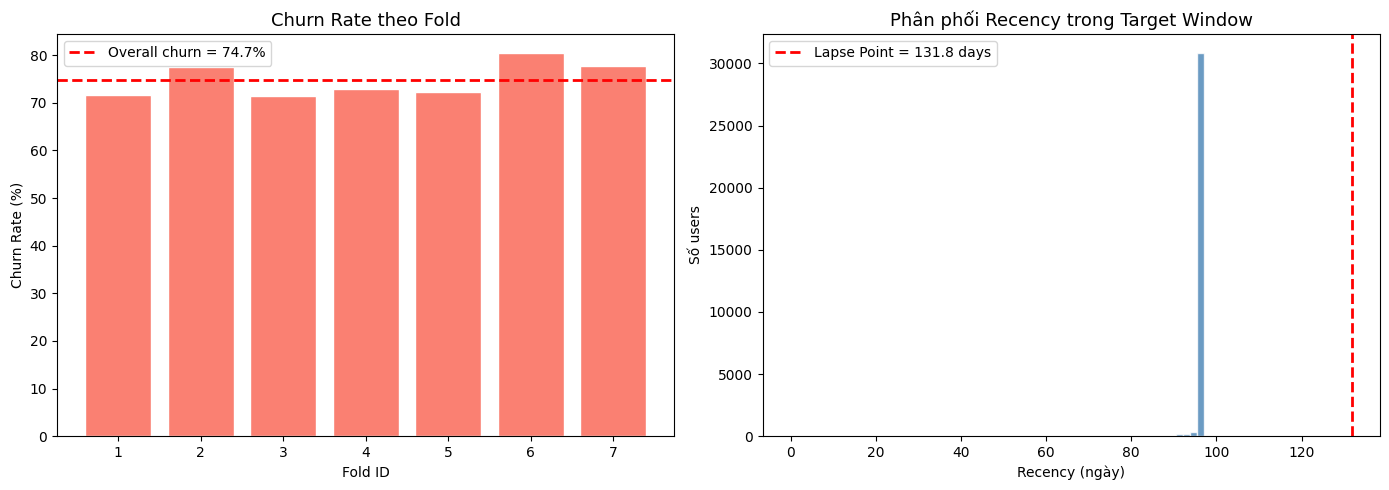

In [8]:
# ==============================================================
# BƯỚC 6: Visualize churn rate & recency distribution
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary['fold_id'], summary['churn_rate_pct'], color='salmon', edgecolor='white')
axes[0].axhline(all_labels['churn'].mean()*100, color='red', linestyle='--',
                linewidth=2, label=f'Overall churn = {all_labels["churn"].mean()*100:.1f}%')
axes[0].set_title('Churn Rate theo Fold', fontsize=13)
axes[0].set_xlabel('Fold ID')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend()

axes[1].hist(all_labels['recency_days'].clip(upper=TARGET_DAYS+5), bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(lapse_point, color='red', linestyle='--', linewidth=2,
                label=f'Lapse Point = {lapse_point:.1f} days')
axes[1].set_title('Phân phối Recency trong Target Window', fontsize=13)
axes[1].set_xlabel('Recency (ngày)')
axes[1].set_ylabel('Số users')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# ==============================================================
# BƯỚC 7: Lưu kết quả
# ==============================================================

out_path = os.path.join(DATA_DIR, 'churn_labels.pkl')
all_labels.to_pickle(out_path)
print(f'Đã lưu: {out_path}')
print(f'Shape: {all_labels.shape}')
print()
print('Columns:')
print(all_labels.dtypes)
print()
print('Sample:')
display(all_labels.head(10))

Đã lưu: c:\Users\Admin\data_driven_marketing\data\churn_labels.pkl
Shape: (32218, 13)

Columns:
fullVisitorId                          str
fold_id                              int64
feature_start               datetime64[ns]
feature_end                 datetime64[ns]
target_start                datetime64[ns]
target_end                  datetime64[ns]
last_purchase_in_feature    datetime64[ns]
recency_past                         int64
is_churn_past                        int64
last_purchase_in_target     datetime64[ns]
purchased_in_target                  int64
recency_days                         int64
churn                                int64
dtype: object

Sample:


,fullVisitorId,fold_id,feature_start,feature_end,target_start,target_end,last_purchase_in_feature,recency_past,is_churn_past,last_purchase_in_target,purchased_in_target,recency_days,churn
0,0002871498069867123,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-08-23 14:55:08,145,1,NaT,0,237,1
1,0003450834640354121,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-10-18 21:20:02,89,0,NaT,0,181,1
2,000435324061339869,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-10-21 01:33:41,87,0,NaT,0,179,1
3,0007617910709180468,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-12-12 16:23:52,34,0,NaT,0,126,0
4,001905118576359487,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-10-17 16:41:36,90,0,NaT,0,182,1
5,0020342483972052451,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-12-07 01:37:42,40,0,NaT,0,132,1
6,0020502892485275044,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-09-11 17:00:44,126,0,NaT,0,218,1
7,0021939395292136520,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-09-17 02:00:45,121,0,NaT,0,213,1
8,0024314485741511650,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2016-12-28 02:10:24,19,0,NaT,0,111,0
9,0024725579067754075,1,2016-08-01 07:00:12,2017-01-16 07:00:12,2017-01-16 07:00:12,2017-04-18 07:00:12,2017-01-05 17:46:51,10,0,NaT,0,102,0


In [15]:
# Gán Churn tổng CHỈ cho khách hàng đã mua hàng
max_date_global = df['event_date'].max()

# Lọc CHỈ các session có giao dịch mua
df_buyers = df[df['transactionRevenue'] > 0].copy()

df_churn = (
    df_buyers.groupby('fullVisitorId').agg(
        last_purchase_date=('event_date', 'max'),
        first_purchase_date=('event_date', 'min'),
        n_purchases=('event_date', 'nunique'),          # Số lần mua (theo ngày)
        total_revenue=('transactionRevenue', 'sum')      # Tổng doanh thu
    )
    .reset_index()
)

# Tính recency
df_churn['recency_total'] = (max_date_global - df_churn['last_purchase_date']).dt.days

# Tính lifetime (số ngày từ lần mua đầu đến lần mua cuối)
df_churn['lifetime_days'] = (df_churn['last_purchase_date'] - df_churn['first_purchase_date']).dt.days

# Tính IPT trung bình của từng khách (chỉ khách mua >= 2 lần)
df_churn['avg_ipt'] = np.where(
    df_churn['n_purchases'] > 1,
    df_churn['lifetime_days'] / (df_churn['n_purchases'] - 1),
    np.nan  # Khách chỉ mua 1 lần thì không tính được IPT
)

# Tính purchase frequency (số lần mua / số tháng hoạt động)
df_churn['purchase_freq_monthly'] = np.where(
    df_churn['lifetime_days'] > 0,
    df_churn['n_purchases'] / (df_churn['lifetime_days'] / 30),
    0
)

# Gán nhãn churn
df_churn['is_churn_total'] = (df_churn['recency_total'] > lapse_point).astype(int)

# Kiểm tra kết quả
print(f"Tổng số khách hàng ĐÃ MUA: {len(df_churn):,}")
print(f"Số khách hàng Churn: {df_churn['is_churn_total'].sum():,}")
print(f"Số khách hàng Active: {(df_churn['is_churn_total'] == 0).sum():,}")
print(f"Tỷ lệ Churn: {df_churn['is_churn_total'].mean()*100:.2f}%")

# Lưu
df_churn.to_csv(os.path.join(DATA_DIR, 'df_churn.csv'))
print(f"\nĐã lưu: {os.path.join(DATA_DIR, 'df_churn.csv')}")


Tổng số khách hàng ĐÃ MUA: 16,141
Số khách hàng Churn: 13,359
Số khách hàng Active: 2,782
Tỷ lệ Churn: 82.76%

Đã lưu: c:\Users\Admin\data_driven_marketing\data\df_churn.csv


In [17]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 16141 entries, 0 to 16140
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   fullVisitorId          16141 non-null  str           
 1   last_purchase_date     16141 non-null  datetime64[ns]
 2   first_purchase_date    16141 non-null  datetime64[ns]
 3   n_purchases            16141 non-null  int64         
 4   total_revenue          16141 non-null  float64       
 5   recency_total          16141 non-null  int64         
 6   lifetime_days          16141 non-null  int64         
 7   avg_ipt                1541 non-null   float64       
 8   purchase_freq_monthly  16141 non-null  float64       
 9   is_churn_total         16141 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(4), str(1)
memory usage: 1.2 MB
